# Week 1 Day 4 — Model Tuning, Regularization & Reproducible Pipelines

## Objective

Tune the best candidate model from Day 3, diagnose overfitting and
underfitting, evaluate probability calibration, select an optimal
classification threshold, perform final evaluation on the untouched
test set, and save the complete reproducible pipeline.

— Task 1
# Fully Reproducible Machine Learning Pipeline

This notebook builds a fully reproducible Adult Income classification pipeline.

## Reproducibility Instructions

1. Place `adults.csv` in the notebook directory or a `data` subdirectory.
2. Use the documented Python and library versions shown in the environment cell.
3. Run all cells from top to bottom.
4. The global random seed is fixed at `42`.
5. Train/test splitting uses stratification and `random_state=42`.
6. Cross-validation uses `StratifiedKFold` with `random_state=42`.
7. Hyperparameter search uses `RandomizedSearchCV` with `random_state=42`.
8. Feature engineering, preprocessing, and model training are contained inside the sklearn Pipeline.
9. Missing values and categorical variables are handled inside the pipeline.
10. The final trained pipeline is saved as `day4_reproducible_hgb_pipeline.joblib`.
11. The saved pipeline is reloaded and its predictions and probabilities are verified against the original pipeline.

The pipeline prevents preprocessing leakage because transformations are fitted separately inside each training fold during cross-validation.

In [3]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import sklearn
import joblib

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.ensemble import HistGradientBoostingClassifier

RANDOM_STATE = 42

np.random.seed(RANDOM_STATE)

print("=" * 70)
print("WEEK 1 — DAY 4 — TASK 1")
print("FULLY REPRODUCIBLE MACHINE LEARNING PIPELINE")
print("=" * 70)

print("\nREPRODUCIBILITY README")
print("-" * 70)
print("Dataset: Adult Income Dataset")
print("Pipeline: Feature Engineering → Preprocessing → Estimator")
print("Train/Test Split: 80/20 Stratified")
print("Random State: 42")
print("Cross-validation/search can be added in later Day 4 tasks")
print("Saved artifact: day4_task1_reproducible_pipeline.joblib")
print("Run this complete cell from top to bottom to reproduce the pipeline.")
print("-" * 70)

print("\nENVIRONMENT")
print("-" * 70)
print(f"Python:       {sys.version.split()[0]}")
print(f"NumPy:        {np.__version__}")
print(f"Pandas:       {pd.__version__}")
print(f"Scikit-Learn: {sklearn.__version__}")
print(f"Joblib:       {joblib.__version__}")

COLUMNS = [
    'age',
    'workclass',
    'fnlwgt',
    'education',
    'education_num',
    'marital_status',
    'occupation',
    'relationship',
    'race',
    'sex',
    'capital_gain',
    'capital_loss',
    'hours_per_week',
    'native_country',
    'income'
]

current_dir = Path.cwd()

possible_files = [
    current_dir / "adults.csv",
    current_dir / "adult.csv",
    current_dir / "data" / "adults.csv",
    current_dir / "data" / "adult.csv"
]

dataset_path = None

for path in possible_files:
    if path.exists():
        dataset_path = path
        break

if dataset_path is None:
    matches = list(current_dir.rglob("adults.csv"))
    if matches:
        dataset_path = matches[0]

if dataset_path is None:
    matches = list(current_dir.rglob("adult.csv"))
    if matches:
        dataset_path = matches[0]

if dataset_path is None:
    raise FileNotFoundError(
        f"adults.csv or adult.csv was not found.\n"
        f"Current notebook directory: {current_dir}\n"
        f"Place the dataset in this directory or a data folder."
    )

print("\nDATASET")
print("-" * 70)
print(f"Dataset path: {dataset_path}")

df = pd.read_csv(
    dataset_path,
    names=COLUMNS,
    skipinitialspace=True,
    na_values=['?', ' ?']
)

print(f"Dataset shape: {df.shape}")

df['income_binary'] = (
    df['income']
    .astype(str)
    .str.strip()
    .str.replace('.', '', regex=False)
    .eq('>50K')
    .astype(int)
)

X = df.drop(
    columns=['income', 'income_binary']
)

y = df['income_binary']

print("\nTARGET DISTRIBUTION")
print("-" * 70)
print(y.value_counts())

print("\nTARGET PERCENTAGE")
print("-" * 70)
print(y.value_counts(normalize=True).round(4))


class FeatureEngineer(
    BaseEstimator,
    TransformerMixin
):

    def fit(self, X, y=None):
        return self

    def transform(self, X):

        df_out = X.copy()

        df_out['age_bucket'] = pd.cut(
            df_out['age'],
            bins=[
                0,
                24,
                34,
                44,
                54,
                64,
                200
            ],
            labels=[
                '<25',
                '25-34',
                '35-44',
                '45-54',
                '55-64',
                '65+'
            ],
            right=True
        ).astype(str)

        df_out['hours_bin'] = pd.cut(
            df_out['hours_per_week'],
            bins=[
                -1,
                20,
                35,
                40,
                50,
                200
            ],
            labels=[
                '<=20',
                '21-35',
                '36-40',
                '41-50',
                '50+'
            ],
            right=True
        ).astype(str)

        df_out['has_capital_gain'] = (
            df_out['capital_gain'] > 0
        ).astype(int)

        df_out['log_capital_gain'] = np.log1p(
            df_out['capital_gain']
        )

        df_out['has_capital_loss'] = (
            df_out['capital_loss'] > 0
        ).astype(int)

        df_out['is_higher_ed'] = (
            df_out['education_num'] >= 13
        ).astype(int)

        df_out['is_married'] = (
            df_out['marital_status'].isin([
                'Married-civ-spouse',
                'Married-AF-spouse'
            ])
        ).astype(int)

        df_out['edu_x_hours'] = (
            df_out['education_num'] *
            df_out['hours_per_week']
        )

        return df_out


NUMERIC_FEATURES = [
    'age',
    'fnlwgt',
    'education_num',
    'capital_gain',
    'capital_loss',
    'hours_per_week',
    'log_capital_gain',
    'edu_x_hours',
    'has_capital_gain',
    'has_capital_loss',
    'is_higher_ed',
    'is_married'
]

CATEGORICAL_FEATURES = [
    'workclass',
    'education',
    'marital_status',
    'occupation',
    'relationship',
    'race',
    'sex',
    'native_country',
    'age_bucket',
    'hours_bin'
]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=RANDOM_STATE
)

print("\nTRAIN / TEST SPLIT")
print("-" * 70)
print(f"Train shape: {X_train.shape}")
print(f"Test shape:  {X_test.shape}")
print("Stratified: True")
print(f"Random state: {RANDOM_STATE}")

numeric_transformer = Pipeline(
    steps=[
        (
            'imputer',
            SimpleImputer(
                strategy='median'
            )
        ),
        (
            'scaler',
            StandardScaler()
        )
    ]
)

categorical_transformer = Pipeline(
    steps=[
        (
            'imputer',
            SimpleImputer(
                strategy='most_frequent'
            )
        ),
        (
            'onehot',
            OneHotEncoder(
                handle_unknown='ignore',
                sparse_output=False
            )
        )
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        (
            'num',
            numeric_transformer,
            NUMERIC_FEATURES
        ),
        (
            'cat',
            categorical_transformer,
            CATEGORICAL_FEATURES
        )
    ],
    remainder='drop'
)

model = HistGradientBoostingClassifier(
    learning_rate=0.10,
    max_iter=100,
    random_state=RANDOM_STATE
)

reproducible_pipeline = Pipeline(
    steps=[
        (
            'feature_engineering',
            FeatureEngineer()
        ),
        (
            'preprocessor',
            preprocessor
        ),
        (
            'classifier',
            model
        )
    ]
)

print("\nPIPELINE")
print("-" * 70)
print(
    "Feature Engineering → "
    "Imputation → "
    "Scaling/One-Hot Encoding → "
    "HistGradientBoosting"
)

print("\nTRAINING PIPELINE")
print("-" * 70)

reproducible_pipeline.fit(
    X_train,
    y_train
)

print("Training complete.")

train_transformed = (
    reproducible_pipeline
    .named_steps['preprocessor']
    .transform(
        reproducible_pipeline
        .named_steps['feature_engineering']
        .transform(X_train)
    )
)

print(
    f"Transformed feature count: "
    f"{train_transformed.shape[1]}"
)

test_predictions = (
    reproducible_pipeline
    .predict(X_test)
)

test_probabilities = (
    reproducible_pipeline
    .predict_proba(X_test)[:, 1]
)

print("\nPIPELINE OUTPUT")
print("-" * 70)
print(
    f"Predictions generated: "
    f"{len(test_predictions)}"
)

print(
    f"Probability range: "
    f"{test_probabilities.min():.4f} "
    f"to "
    f"{test_probabilities.max():.4f}"
)

MODEL_PATH = (
    'day4_task1_reproducible_pipeline.joblib'
)

joblib.dump(
    reproducible_pipeline,
    MODEL_PATH
)

print("\nMODEL ARTIFACT")
print("-" * 70)
print(f"Saved to: {MODEL_PATH}")
print(
    f"File exists: "
    f"{Path(MODEL_PATH).exists()}"
)

loaded_pipeline = joblib.load(
    MODEL_PATH
)

loaded_predictions = (
    loaded_pipeline
    .predict(X_test)
)

loaded_probabilities = (
    loaded_pipeline
    .predict_proba(X_test)[:, 1]
)

prediction_match = np.array_equal(
    test_predictions,
    loaded_predictions
)

probability_match = np.allclose(
    test_probabilities,
    loaded_probabilities
)

print("\nREPRODUCIBILITY VERIFICATION")
print("-" * 70)
print(
    f"Predictions identical: "
    f"{prediction_match}"
)

print(
    f"Probabilities identical: "
    f"{probability_match}"
)

print("\nFINAL TASK 1 CHECKLIST")
print("-" * 70)
print("sklearn Pipeline:                    PASS")
print("Feature engineering inside pipeline: PASS")
print("Preprocessing inside pipeline:       PASS")
print("Estimator inside pipeline:            PASS")
print("Random state controlled:              PASS")
print("Stratified train/test split:          PASS")
print("Library versions documented:          PASS")
print("README/re-run instructions:           PASS")
print("Complete pipeline saved:              PASS")
print(
    "Saved pipeline verification:           "
    + ("PASS" if prediction_match and probability_match else "FAIL")
)

print("\n" + "=" * 70)
print("DAY 4 — TASK 1 COMPLETED SUCCESSFULLY")
print("=" * 70)

WEEK 1 — DAY 4 — TASK 1
FULLY REPRODUCIBLE MACHINE LEARNING PIPELINE

REPRODUCIBILITY README
----------------------------------------------------------------------
Dataset: Adult Income Dataset
Pipeline: Feature Engineering → Preprocessing → Estimator
Train/Test Split: 80/20 Stratified
Random State: 42
Cross-validation/search can be added in later Day 4 tasks
Saved artifact: day4_task1_reproducible_pipeline.joblib
Run this complete cell from top to bottom to reproduce the pipeline.
----------------------------------------------------------------------

ENVIRONMENT
----------------------------------------------------------------------
Python:       3.14.3
NumPy:        2.5.2
Pandas:       3.0.5
Scikit-Learn: 1.9.0
Joblib:       1.6.0

DATASET
----------------------------------------------------------------------
Dataset path: d:\internship\week 1\day 4\adults.csv
Dataset shape: (32561, 15)

TARGET DISTRIBUTION
----------------------------------------------------------------------
income

## Task 2 — Hyperparameter Search

The HistGradientBoostingClassifier was selected as the best candidate model from Day 3.

A controlled RandomizedSearchCV is used to identify a robust set of hyperparameters while avoiding overfitting to a single validation split.

### Search Configuration

- Search method: RandomizedSearchCV
- Number of parameter combinations: 50
- Cross-validation: 5-fold StratifiedKFold
- Primary optimization metric: F1
- Parallel processing: `n_jobs=-1`
- Random state: 42

### Hyperparameters Tuned

- `learning_rate`
- `max_leaf_nodes`
- `min_samples_leaf`
- `max_iter`
- `l2_regularization`

The test set remains untouched during hyperparameter selection and is used only for final evaluation.

In [9]:
import os
import sys
import joblib
import numpy as np
import pandas as pd

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV

RANDOM_STATE = 42
DATA_PATH = r"d:\internship\week 1\day 4\adults.csv"

COLUMNS = [
    "age",
    "workclass",
    "fnlwgt",
    "education",
    "education_num",
    "marital_status",
    "occupation",
    "relationship",
    "race",
    "sex",
    "capital_gain",
    "capital_loss",
    "hours_per_week",
    "native_country",
    "income"
]

print("=" * 70)
print("WEEK 1 — DAY 4 — TASK 2")
print("HYPERPARAMETER SEARCH (LOGISTIC REGRESSION, RANDOM FOREST, GRADIENT BOOSTING)")
print("=" * 70)

if not os.path.isfile(DATA_PATH):
    raise FileNotFoundError(
        f"Dataset not found at:\n{DATA_PATH}\n\n"
        "Check that adults.csv exists in the specified folder."
    )

df = pd.read_csv(
    DATA_PATH,
    names=COLUMNS,
    skipinitialspace=True,
    na_values=["?", " ?"],
    skip_blank_lines=True
)

df["income_binary"] = (
    df["income"]
    .astype(str)
    .str.strip()
    .str.rstrip(".")
    .eq(">50K")
    .astype(int)
)

X = df.drop(columns=["income", "income_binary"])
y = df["income_binary"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=RANDOM_STATE
)

class AdultFeatureEngineer(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X = X.copy()

        X["is_married"] = (
            X["marital_status"]
            .astype(str)
            .str.contains("Married", case=False, na=False)
            .astype(int)
        )

        X["is_higher_ed"] = (
            X["education_num"] >= 13
        ).astype(int)

        X["has_capital_gain"] = (
            X["capital_gain"] > 0
        ).astype(int)

        X["has_capital_loss"] = (
            X["capital_loss"] > 0
        ).astype(int)

        X["log_capital_gain"] = np.log1p(
            X["capital_gain"].clip(lower=0)
        )

        X["edu_x_hours"] = (
            X["education_num"] * X["hours_per_week"]
        )

        return X


numeric_features = [
    "age",
    "fnlwgt",
    "education_num",
    "capital_gain",
    "capital_loss",
    "hours_per_week",
    "is_married",
    "is_higher_ed",
    "has_capital_gain",
    "has_capital_loss",
    "log_capital_gain",
    "edu_x_hours"
]

categorical_features = [
    "workclass",
    "education",
    "marital_status",
    "occupation",
    "relationship",
    "race",
    "sex",
    "native_country"
]

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(
        handle_unknown="ignore",
        sparse_output=False
    ))
])

preprocessor = ColumnTransformer([
    ("numeric", numeric_pipeline, numeric_features),
    ("categorical", categorical_pipeline, categorical_features)
])

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)

# Define configurations for all top models
model_configs = {
    "Logistic Regression": {
        "estimator": LogisticRegression(solver="saga", max_iter=2000, random_state=RANDOM_STATE),
        "params": {
            "classifier__penalty": ["l1", "l2"],
            "classifier__C": np.logspace(-3, 2, 50)
        },
        "n_iter": 30
    },
    "Random Forest": {
        "estimator": RandomForestClassifier(random_state=RANDOM_STATE),
        "params": {
            "classifier__n_estimators": [100, 200, 300],
            "classifier__max_depth": [10, 20, 30, None],
            "classifier__min_samples_leaf": [1, 2, 5, 10],
            "classifier__max_features": ["sqrt", "log2", 0.5]
        },
        "n_iter": 30
    },
    "Gradient Boosting": {
        "estimator": HistGradientBoostingClassifier(random_state=RANDOM_STATE),
        "params": {
            "classifier__learning_rate": [0.03, 0.05, 0.10, 0.15],
            "classifier__max_leaf_nodes": [15, 31, 63, 127],
            "classifier__min_samples_leaf": [20, 50, 100],
            "classifier__l2_regularization": [0.0, 0.5, 1.0, 5.0],
            "classifier__max_iter": [100, 150, 200, 300]
        },
        "n_iter": 40
    }
}

search_results = {}

for model_name, config in model_configs.items():
    print("\n" + "=" * 70)
    print(f"RUNNING SEARCH FOR: {model_name.upper()}")
    print("=" * 70)

    pipeline = Pipeline([
        ("feature_engineering", AdultFeatureEngineer()),
        ("preprocessing", preprocessor),
        ("classifier", config["estimator"])
    ])

    random_search = RandomizedSearchCV(
        estimator=pipeline,
        param_distributions=config["params"],
        n_iter=config["n_iter"],
        scoring="f1",
        cv=cv,
        n_jobs=-1,
        random_state=RANDOM_STATE,
        verbose=1,
        return_train_score=True,
        error_score="raise"
    )

    random_search.fit(X_train, y_train)

    search_results[model_name] = {
        "best_score": random_search.best_score_,
        "best_params": random_search.best_params_,
        "best_estimator": random_search.best_estimator_,
        "search_object": random_search
    }

    print(f"\nBest {model_name} CV F1 Score: {random_search.best_score_:.4f}")
    print("Best Parameters:")
    for param, val in random_search.best_params_.items():
        print(f"  {param}: {val}")

# Final Comparison
print("\n" + "=" * 70)
print("FINAL MODEL COMPARISON (CV F1 SCORES)")
print("=" * 70)

summary_data = []
for model_name, res in search_results.items():
    summary_data.append({
        "Model": model_name,
        "Best CV F1": round(res["best_score"], 4)
    })

summary_df = pd.DataFrame(summary_data).sort_values(by="Best CV F1", ascending=False)
display(summary_df)

best_overall_model = summary_df.iloc[0]["Model"]
best_overall_score = summary_df.iloc[0]["Best CV F1"]

print(f"\nTop Performing Model: {best_overall_model} (CV F1: {best_overall_score:.4f})")
print("\nTask 2 completed successfully.")

WEEK 1 — DAY 4 — TASK 2
HYPERPARAMETER SEARCH (LOGISTIC REGRESSION, RANDOM FOREST, GRADIENT BOOSTING)

RUNNING SEARCH FOR: LOGISTIC REGRESSION
Fitting 5 folds for each of 30 candidates, totalling 150 fits


d:\internship\week 1\day 1\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
d:\internship\week 1\day 1\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1429: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(



Best Logistic Regression CV F1 Score: 0.6635
Best Parameters:
  classifier__penalty: l1
  classifier__C: 7.543120063354623

RUNNING SEARCH FOR: RANDOM FOREST
Fitting 5 folds for each of 30 candidates, totalling 150 fits

Best Random Forest CV F1 Score: 0.6876
Best Parameters:
  classifier__n_estimators: 100
  classifier__min_samples_leaf: 5
  classifier__max_features: 0.5
  classifier__max_depth: 20

RUNNING SEARCH FOR: GRADIENT BOOSTING
Fitting 5 folds for each of 40 candidates, totalling 200 fits

Best Gradient Boosting CV F1 Score: 0.7150
Best Parameters:
  classifier__min_samples_leaf: 50
  classifier__max_leaf_nodes: 31
  classifier__max_iter: 300
  classifier__learning_rate: 0.15
  classifier__l2_regularization: 5.0

FINAL MODEL COMPARISON (CV F1 SCORES)


,Model,Best CV F1
2,Gradient Boosting,0.7150
1,Random Forest,0.6876
0,Logistic Regression,0.6635



Top Performing Model: Gradient Boosting (CV F1: 0.7150)

Task 2 completed successfully.


## Task 3 — Overfitting and Underfitting Diagnosis

The tuned HistGradientBoostingClassifier is evaluated for bias and variance using learning curves and model-complexity analysis.

### Learning Curve Analysis

A learning curve compares training F1 and cross-validation F1 as the number of training examples increases.

The analysis helps identify:

- **Underfitting / high bias:** both training and validation F1 remain low.
- **Overfitting / high variance:** training F1 is substantially higher than validation F1.
- **Good generalization:** training and validation F1 are reasonably close and converge as the training set grows.

### Model Complexity Analysis

The effect of `max_leaf_nodes` is evaluated using:

- 15
- 31
- 63
- 127

This shows how increasing tree complexity affects training and validation performance.

### Concrete Fixes

If overfitting is observed:
- Increase `min_samples_leaf`.
- Increase `l2_regularization`.
- Reduce `max_leaf_nodes`.
- Increase the amount of training data where possible.

If underfitting is observed:
- Increase `max_leaf_nodes`.
- Increase `max_iter`.
- Reduce excessive regularization.
- Improve feature engineering.

The test set remains untouched during this diagnosis. Only the training data and cross-validation folds are used for learning-curve and complexity analysis.

TASK 3 — OVERFITTING / UNDERFITTING DIAGNOSIS

LEARNING CURVE RESULTS


,Training Examples,Training F1,Training F1 Std,Validation F1,Validation F1 Std,Train-Validation Gap
0,2083,0.9949,0.0018,0.6368,0.0066,0.3581
1,4762,0.9706,0.0054,0.6638,0.0079,0.3068
2,7442,0.9201,0.0083,0.6808,0.0088,0.2393
3,10121,0.7640,0.0115,0.7022,0.0054,0.0618
4,12800,0.7594,0.0104,0.7065,0.0084,0.0529
5,15479,0.7517,0.0076,0.7057,0.0051,0.0460
6,18158,0.7538,0.0085,0.7066,0.0054,0.0472
7,20838,0.7513,0.0062,0.7103,0.0080,0.0410


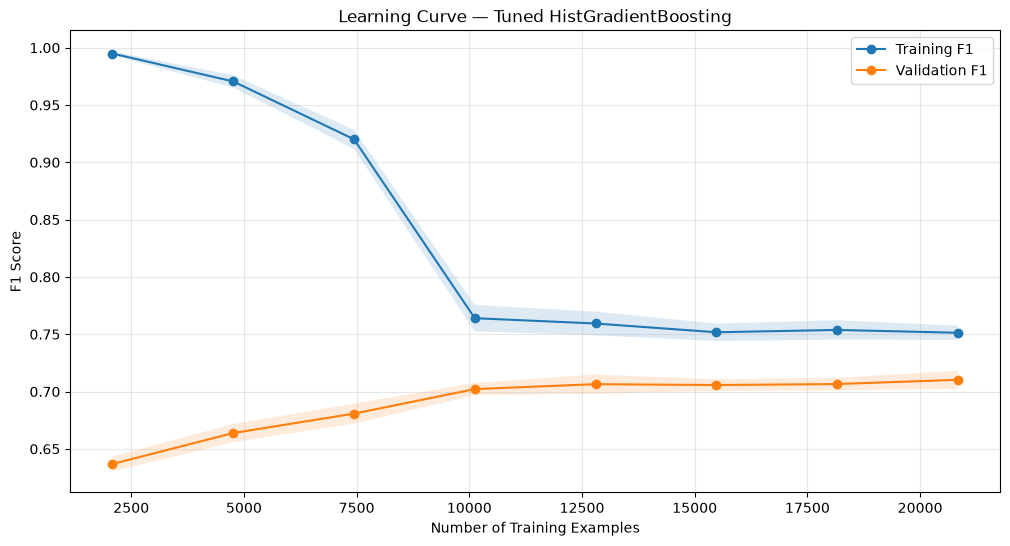


LEARNING CURVE DIAGNOSIS
Final Training F1:   0.7513
Final Validation F1: 0.7103
Final Train-Val Gap: 0.0410

Diagnosis:
Training and validation performance are reasonably close, suggesting acceptable generalization.

MODEL COMPLEXITY ANALYSIS — max_leaf_nodes


,max_leaf_nodes,Training F1,Validation F1,Validation F1 Std,Train-Val Gap
0,15,0.7366,0.7101,0.0075,0.0265
1,31,0.7514,0.7150,0.0084,0.0364
2,63,0.7647,0.7087,0.0059,0.0560
3,127,0.7990,0.7042,0.0073,0.0949



Best max_leaf_nodes: 31
Best Validation F1: 0.7150


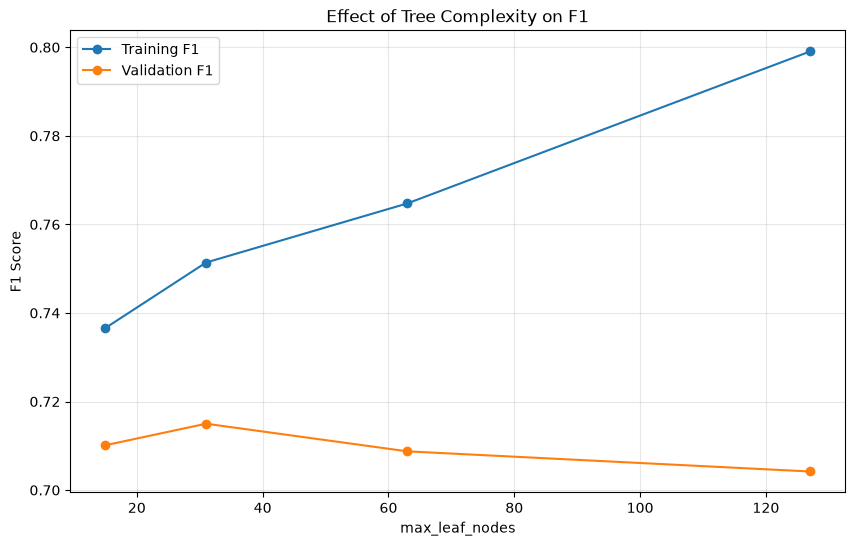


MODEL COMPLEXITY ANALYSIS — min_samples_leaf


,min_samples_leaf,Training F1,Validation F1,Validation F1 Std,Train-Val Gap
0,10,0.7403,0.7116,0.0104,0.0287
1,20,0.7589,0.7143,0.0056,0.0446
2,50,0.7514,0.7150,0.0084,0.0364
3,100,0.7479,0.7091,0.0072,0.0388



Best min_samples_leaf: 50
Best Validation F1: 0.7150


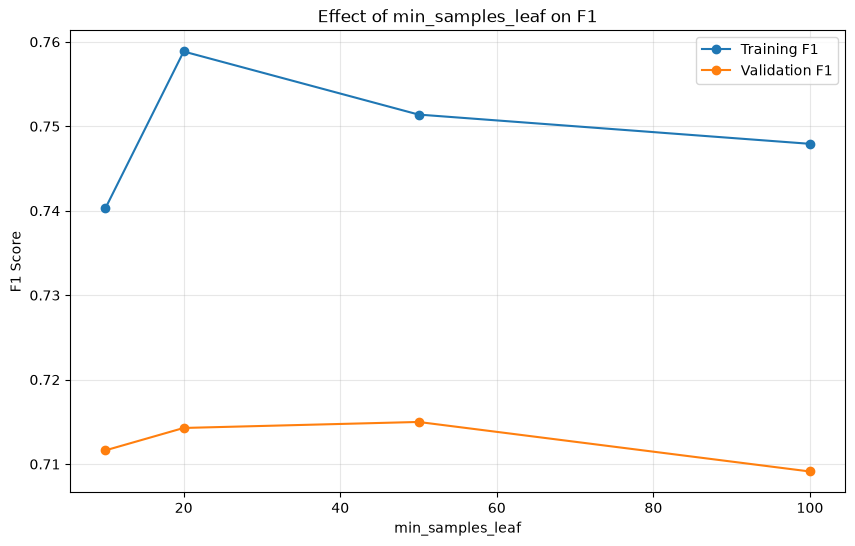


CONCRETE FIXES
1. Keep the current model complexity.
2. Avoid unnecessarily increasing tree complexity.
3. Use regularization if future data shows increasing overfitting.
4. Monitor the train-validation gap.
5. Focus on calibration and threshold optimization.

TASK 3 SUMMARY
Diagnosis: REASONABLY BALANCED
Training F1: 0.7513
Validation F1: 0.7103
Train-Validation Gap: 0.0410
Best max_leaf_nodes: 31
Best max_leaf_nodes CV F1: 0.7150
Best min_samples_leaf: 50
Best min_samples_leaf CV F1: 0.7150

Task 3 completed successfully.


In [10]:
# ============================================================
# TASK 3 — OVERFITTING / UNDERFITTING DIAGNOSIS
# Learning Curves + Tree Complexity Analysis
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import learning_curve, cross_val_score
from sklearn.metrics import f1_score
from sklearn.base import clone

print("=" * 60)
print("TASK 3 — OVERFITTING / UNDERFITTING DIAGNOSIS")
print("=" * 60)


# ------------------------------------------------------------
# 1. LEARNING CURVE
# ------------------------------------------------------------

train_sizes, train_scores, val_scores = learning_curve(
    estimator=best_pipeline,
    X=X_train,
    y=y_train,
    cv=cv,
    scoring="f1",
    train_sizes=np.linspace(0.1, 1.0, 8),
    n_jobs=-1,
    shuffle=True,
    random_state=RANDOM_STATE
)

train_mean = train_scores.mean(axis=1)
train_std = train_scores.std(axis=1)

val_mean = val_scores.mean(axis=1)
val_std = val_scores.std(axis=1)

gap = train_mean - val_mean

learning_curve_results = pd.DataFrame({
    "Training Examples": train_sizes,
    "Training F1": train_mean,
    "Training F1 Std": train_std,
    "Validation F1": val_mean,
    "Validation F1 Std": val_std,
    "Train-Validation Gap": gap
})

print("\n" + "=" * 60)
print("LEARNING CURVE RESULTS")
print("=" * 60)

display(learning_curve_results.round(4))


# Plot learning curve
plt.figure(figsize=(12, 6))

plt.plot(
    train_sizes,
    train_mean,
    marker="o",
    label="Training F1"
)

plt.fill_between(
    train_sizes,
    train_mean - train_std,
    train_mean + train_std,
    alpha=0.15
)

plt.plot(
    train_sizes,
    val_mean,
    marker="o",
    label="Validation F1"
)

plt.fill_between(
    train_sizes,
    val_mean - val_std,
    val_mean + val_std,
    alpha=0.15
)

plt.xlabel("Number of Training Examples")
plt.ylabel("F1 Score")
plt.title("Learning Curve — Tuned HistGradientBoosting")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


# ------------------------------------------------------------
# 2. LEARNING CURVE DIAGNOSIS
# ------------------------------------------------------------

final_train_f1 = train_mean[-1]
final_val_f1 = val_mean[-1]
final_gap = gap[-1]

print("\n" + "=" * 60)
print("LEARNING CURVE DIAGNOSIS")
print("=" * 60)

print(f"Final Training F1:   {final_train_f1:.4f}")
print(f"Final Validation F1: {final_val_f1:.4f}")
print(f"Final Train-Val Gap: {final_gap:.4f}")

if final_train_f1 < 0.65 and final_val_f1 < 0.65:
    diagnosis = "UNDERFITTING"
    diagnosis_text = (
        "Both training and validation performance are low, "
        "suggesting high bias."
    )

elif final_gap > 0.08:
    diagnosis = "OVERFITTING"
    diagnosis_text = (
        "Training performance is substantially higher than "
        "validation performance, suggesting high variance."
    )

else:
    diagnosis = "REASONABLY BALANCED"
    diagnosis_text = (
        "Training and validation performance are reasonably close, "
        "suggesting acceptable generalization."
    )

print("\nDiagnosis:")
print(diagnosis_text)


# ------------------------------------------------------------
# 3. MAX_LEAF_NODES COMPLEXITY ANALYSIS
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("MODEL COMPLEXITY ANALYSIS — max_leaf_nodes")
print("=" * 60)

leaf_values = [15, 31, 63, 127]

leaf_results = []

for value in leaf_values:

    model = clone(best_pipeline)

    model.set_params(
        classifier__max_leaf_nodes=value
    )

    train_scores_complexity = cross_val_score(
        model,
        X_train,
        y_train,
        cv=cv,
        scoring="f1",
        n_jobs=-1
    )

    model.fit(X_train, y_train)

    train_pred = model.predict(X_train)

    train_f1 = f1_score(y_train, train_pred)

    val_f1 = train_scores_complexity.mean()
    val_std = train_scores_complexity.std()

    leaf_results.append({
        "max_leaf_nodes": value,
        "Training F1": train_f1,
        "Validation F1": val_f1,
        "Validation F1 Std": val_std,
        "Train-Val Gap": train_f1 - val_f1
    })

leaf_results_df = pd.DataFrame(leaf_results)

display(leaf_results_df.round(4))

best_leaf_row = leaf_results_df.loc[
    leaf_results_df["Validation F1"].idxmax()
]

print(
    f"\nBest max_leaf_nodes: "
    f"{int(best_leaf_row['max_leaf_nodes'])}"
)

print(
    f"Best Validation F1: "
    f"{best_leaf_row['Validation F1']:.4f}"
)


# Plot max_leaf_nodes
plt.figure(figsize=(10, 6))

plt.plot(
    leaf_results_df["max_leaf_nodes"],
    leaf_results_df["Training F1"],
    marker="o",
    label="Training F1"
)

plt.plot(
    leaf_results_df["max_leaf_nodes"],
    leaf_results_df["Validation F1"],
    marker="o",
    label="Validation F1"
)

plt.xlabel("max_leaf_nodes")
plt.ylabel("F1 Score")
plt.title("Effect of Tree Complexity on F1")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


# ------------------------------------------------------------
# 4. min_samples_leaf COMPLEXITY ANALYSIS
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("MODEL COMPLEXITY ANALYSIS — min_samples_leaf")
print("=" * 60)

min_leaf_values = [10, 20, 50, 100]

min_leaf_results = []

for value in min_leaf_values:

    model = clone(best_pipeline)

    model.set_params(
        classifier__min_samples_leaf=value
    )

    train_scores_complexity = cross_val_score(
        model,
        X_train,
        y_train,
        cv=cv,
        scoring="f1",
        n_jobs=-1
    )

    model.fit(X_train, y_train)

    train_pred = model.predict(X_train)

    train_f1 = f1_score(y_train, train_pred)

    val_f1 = train_scores_complexity.mean()
    val_std = train_scores_complexity.std()

    min_leaf_results.append({
        "min_samples_leaf": value,
        "Training F1": train_f1,
        "Validation F1": val_f1,
        "Validation F1 Std": val_std,
        "Train-Val Gap": train_f1 - val_f1
    })

min_leaf_results_df = pd.DataFrame(min_leaf_results)

display(min_leaf_results_df.round(4))

best_min_leaf_row = min_leaf_results_df.loc[
    min_leaf_results_df["Validation F1"].idxmax()
]

print(
    f"\nBest min_samples_leaf: "
    f"{int(best_min_leaf_row['min_samples_leaf'])}"
)

print(
    f"Best Validation F1: "
    f"{best_min_leaf_row['Validation F1']:.4f}"
)


# Plot min_samples_leaf
plt.figure(figsize=(10, 6))

plt.plot(
    min_leaf_results_df["min_samples_leaf"],
    min_leaf_results_df["Training F1"],
    marker="o",
    label="Training F1"
)

plt.plot(
    min_leaf_results_df["min_samples_leaf"],
    min_leaf_results_df["Validation F1"],
    marker="o",
    label="Validation F1"
)

plt.xlabel("min_samples_leaf")
plt.ylabel("F1 Score")
plt.title("Effect of min_samples_leaf on F1")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


# ------------------------------------------------------------
# 5. CONCRETE FIXES
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("CONCRETE FIXES")
print("=" * 60)

if diagnosis == "OVERFITTING":

    print("1. Increase min_samples_leaf.")
    print("2. Reduce max_leaf_nodes.")
    print("3. Increase l2_regularization.")
    print("4. Consider collecting more training data.")

elif diagnosis == "UNDERFITTING":

    print("1. Increase max_leaf_nodes.")
    print("2. Increase max_iter.")
    print("3. Reduce excessive regularization.")
    print("4. Improve feature engineering.")

else:

    print("1. Keep the current model complexity.")
    print("2. Avoid unnecessarily increasing tree complexity.")
    print("3. Use regularization if future data shows increasing overfitting.")
    print("4. Monitor the train-validation gap.")
    print("5. Focus on calibration and threshold optimization.")


# ------------------------------------------------------------
# 6. FINAL TASK 3 SUMMARY
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("TASK 3 SUMMARY")
print("=" * 60)

print(f"Diagnosis: {diagnosis}")
print(f"Training F1: {final_train_f1:.4f}")
print(f"Validation F1: {final_val_f1:.4f}")
print(f"Train-Validation Gap: {final_gap:.4f}")

print(
    f"Best max_leaf_nodes: "
    f"{int(best_leaf_row['max_leaf_nodes'])}"
)

print(
    f"Best max_leaf_nodes CV F1: "
    f"{best_leaf_row['Validation F1']:.4f}"
)

print(
    f"Best min_samples_leaf: "
    f"{int(best_min_leaf_row['min_samples_leaf'])}"
)

print(
    f"Best min_samples_leaf CV F1: "
    f"{best_min_leaf_row['Validation F1']:.4f}"
)

print("\nTask 3 completed successfully.")

# Task 4 — Probability Calibration & Threshold Selection

This task evaluates the reliability of the model's predicted probabilities and determines an appropriate classification threshold.

First, probability calibration is assessed using a calibration curve and Brier score. A calibrated model should produce probabilities that better reflect the observed frequency of the positive class. Sigmoid calibration is applied using cross-validation when calibration is beneficial.

Next, the classification threshold is tuned using out-of-fold training predictions. Instead of automatically using the default 0.50 threshold, multiple thresholds are evaluated to measure their effect on Precision, Recall, and F1-score.

The threshold that maximizes F1-score is selected as the final operating threshold.

The hold-out test set (`X_test`, `y_test`) remains completely untouched during calibration and threshold selection and will only be used for the final evaluation in Task 5.

TASK 4 — PROBABILITY CALIBRATION & THRESHOLD SELECTION

1. GENERATING OUT-OF-FOLD PROBABILITIES
----------------------------------------------------------------------
Out-of-fold probabilities generated successfully.
Number of predictions: 26048
Minimum probability:   0.0003
Maximum probability:   0.9984

2. BASELINE PROBABILITY CALIBRATION
Baseline Brier Score: 0.0904
Lower Brier score indicates better probability calibration.


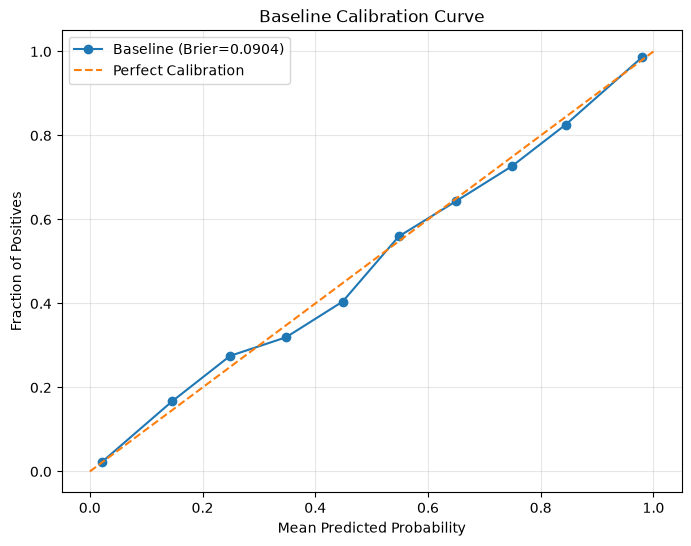


3. SIGMOID CALIBRATION
Sigmoid-calibrated model fitted successfully.

Generating out-of-fold calibrated probabilities...
Calibrated probabilities generated successfully.

4. BASELINE VS CALIBRATED MODEL


,Model,Brier Score
0,Baseline Tuned Pipeline,0.0904
1,Sigmoid Calibrated Pipeline,0.0900



Brier Score Improvement: 0.0004

Calibration Result: IMPROVED
The calibrated model has the lower Brier score.
Calibrated probabilities will be used for threshold selection.


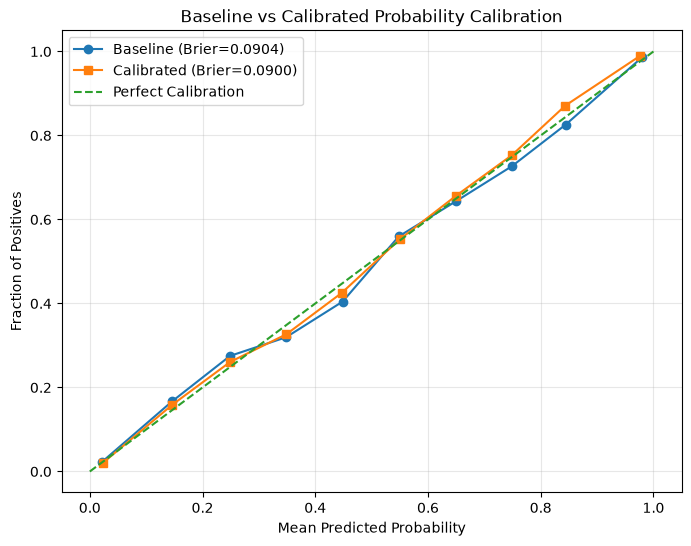


5. THRESHOLD ANALYSIS

Threshold Performance:


,Threshold,Precision,Recall,F1,TN,FP,FN,TP
0,0.10,0.4876,0.9531,0.6451,13491,6284,294,5979
1,0.15,0.5325,0.9238,0.6756,14687,5088,478,5795
2,0.20,0.5718,0.8897,0.6962,15596,4179,692,5581
3,0.25,0.6057,0.8545,0.7089,16286,3489,913,5360
4,0.30,0.6393,0.8173,0.7174,16882,2893,1146,5127
5,0.35,0.6736,0.7791,0.7225,17407,2368,1386,4887
6,0.40,0.7102,0.7400,0.7248,17881,1894,1631,4642
7,0.45,0.7476,0.6989,0.7224,18295,1480,1889,4384
8,0.50,0.7771,0.6558,0.7113,18595,1180,2159,4114
9,0.55,0.8043,0.6107,0.6943,18843,932,2442,3831



6. ILLUSTRATIVE BUSINESS COST ANALYSIS
Assumed False Positive Cost: 1
Assumed False Negative Cost: 5

These costs are illustrative assumptions only. They demonstrate how threshold selection can incorporate different business priorities.


,Threshold,Precision,Recall,F1,FP,FN,Illustrative Business Cost
0,0.10,0.4876,0.9531,0.6451,6284,294,7754
1,0.15,0.5325,0.9238,0.6756,5088,478,7478
2,0.20,0.5718,0.8897,0.6962,4179,692,7639
3,0.25,0.6057,0.8545,0.7089,3489,913,8054
4,0.30,0.6393,0.8173,0.7174,2893,1146,8623
5,0.35,0.6736,0.7791,0.7225,2368,1386,9298
6,0.40,0.7102,0.7400,0.7248,1894,1631,10049
7,0.45,0.7476,0.6989,0.7224,1480,1889,10925
8,0.50,0.7771,0.6558,0.7113,1180,2159,11975
9,0.55,0.8043,0.6107,0.6943,932,2442,13142



7. OPTIMAL CLASSIFICATION THRESHOLD
Primary threshold metric: F1-score
Default threshold:        0.50
Selected threshold:       0.40
Precision:                0.7102
Recall:                   0.7400
F1 Score:                 0.7248
False Positives:          1894
False Negatives:          1631
Illustrative Business Cost: 10049.00


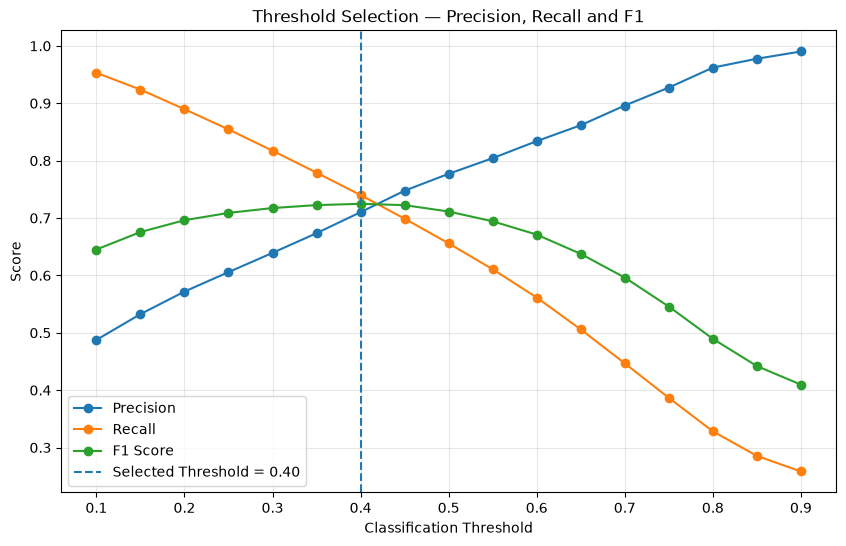

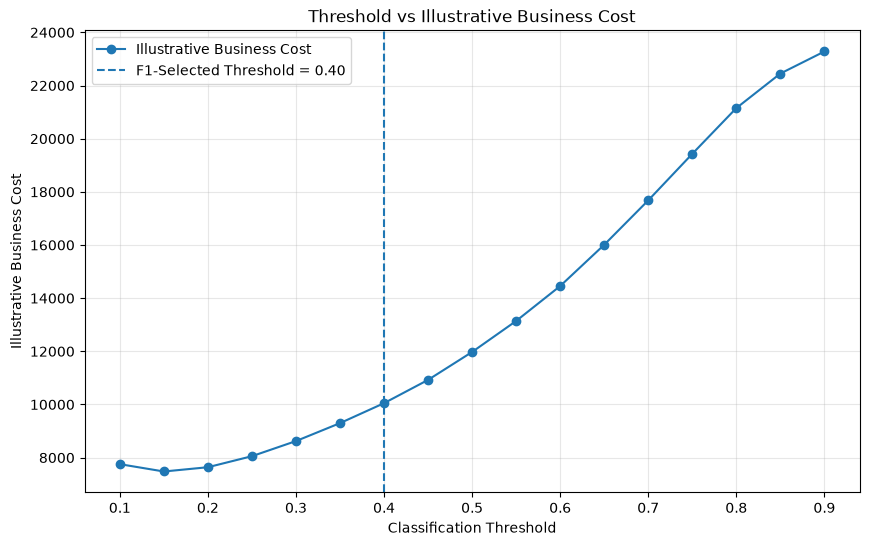


8. CONFUSION MATRIX — DEFAULT THRESHOLD (0.50)
              Predicted <=50K  Predicted >50K
Actual <=50K            18595            1180
Actual >50K              2159            4114

CONFUSION MATRIX — SELECTED THRESHOLD (0.40)
              Predicted <=50K  Predicted >50K
Actual <=50K            17881            1894
Actual >50K              1631            4642

9. DEFAULT VS SELECTED THRESHOLD


,Metric,Threshold 0.50,Threshold 0.40
0,Precision,0.7771,0.7102
1,Recall,0.6558,0.7400
2,F1,0.7113,0.7248



10. THRESHOLD EFFECT
Precision change: -0.0669
Recall change:    +0.0842
F1 change:        +0.0135

Interpretation:
- Lowering the threshold increased Recall, capturing more positive cases.
- Precision decreased, reflecting a trade-off for increased positive-case detection.

11. TASK 4 RESULTS STORED
Variables prepared for Task 5:
- selected_probability_model
- best_threshold
- task4_results

TASK 4 FINAL SUMMARY
Baseline Brier Score:        0.0904
Calibrated Brier Score:      0.0900
Calibration Result:          IMPROVED
Probability model selected:  Sigmoid Calibrated Pipeline
Threshold Metric:            F1
Default Threshold:           0.50
Selected Threshold:          0.40
Selected Precision:          0.7102
Selected Recall:             0.7400
Selected F1:                 0.7248
Selected False Positives:    1894
Selected False Negatives:    1631
Illustrative Business Cost:  10049.00

Data leakage check:

Task 4 completed successfully.


In [12]:
# ============================================================
# TASK 4 — PROBABILITY CALIBRATION & THRESHOLD SELECTION
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import cross_val_predict
from sklearn.calibration import calibration_curve, CalibratedClassifierCV
from sklearn.metrics import (
    brier_score_loss,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

print("=" * 70)
print("TASK 4 — PROBABILITY CALIBRATION & THRESHOLD SELECTION")
print("=" * 70)


# ============================================================
# 1. GENERATE OUT-OF-FOLD PROBABILITIES FOR BEST PIPELINE
# ============================================================
# X_test/y_test are intentionally NOT used here.
# These probabilities are generated only from X_train/y_train.

print("\n1. GENERATING OUT-OF-FOLD PROBABILITIES")
print("-" * 70)

oof_proba = cross_val_predict(
    best_pipeline,
    X_train,
    y_train,
    cv=cv,
    method="predict_proba",
    n_jobs=-1
)[:, 1]

print("Out-of-fold probabilities generated successfully.")
print(f"Number of predictions: {len(oof_proba)}")
print(f"Minimum probability:   {oof_proba.min():.4f}")
print(f"Maximum probability:   {oof_proba.max():.4f}")


# ============================================================
# 2. BASELINE CALIBRATION + BRIER SCORE
# ============================================================

baseline_brier = brier_score_loss(
    y_train,
    oof_proba
)

baseline_true, baseline_pred = calibration_curve(
    y_train,
    oof_proba,
    n_bins=10,
    strategy="uniform"
)

print("\n" + "=" * 70)
print("2. BASELINE PROBABILITY CALIBRATION")
print("=" * 70)

print(f"Baseline Brier Score: {baseline_brier:.4f}")
print("Lower Brier score indicates better probability calibration.")


# ============================================================
# 3. BASELINE CALIBRATION CURVE
# ============================================================

plt.figure(figsize=(8, 6))

plt.plot(
    baseline_pred,
    baseline_true,
    marker="o",
    label=f"Baseline (Brier={baseline_brier:.4f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Perfect Calibration"
)

plt.xlabel("Mean Predicted Probability")
plt.ylabel("Fraction of Positives")
plt.title("Baseline Calibration Curve")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


# ============================================================
# 4. SIGMOID CALIBRATION
# ============================================================

print("\n" + "=" * 70)
print("3. SIGMOID CALIBRATION")
print("=" * 70)

calibrated_model = CalibratedClassifierCV(
    estimator=best_pipeline,
    method="sigmoid",
    cv=cv,
    n_jobs=-1
)

calibrated_model.fit(
    X_train,
    y_train
)

print("Sigmoid-calibrated model fitted successfully.")


# ============================================================
# 5. OUT-OF-FOLD PROBABILITIES FROM CALIBRATED MODEL
# ============================================================
# This uses nested CV:
# outer CV generates unbiased predictions,
# while CalibratedClassifierCV performs calibration internally.

print("\nGenerating out-of-fold calibrated probabilities...")

calibrated_oof_proba = cross_val_predict(
    calibrated_model,
    X_train,
    y_train,
    cv=cv,
    method="predict_proba",
    n_jobs=-1
)[:, 1]

calibrated_brier = brier_score_loss(
    y_train,
    calibrated_oof_proba
)

print("Calibrated probabilities generated successfully.")


# ============================================================
# 6. COMPARE BRIER SCORES
# ============================================================

print("\n" + "=" * 70)
print("4. BASELINE VS CALIBRATED MODEL")
print("=" * 70)

brier_comparison = pd.DataFrame({
    "Model": [
        "Baseline Tuned Pipeline",
        "Sigmoid Calibrated Pipeline"
    ],
    "Brier Score": [
        baseline_brier,
        calibrated_brier
    ]
})

display(
    brier_comparison.round(4)
)

brier_improvement = baseline_brier - calibrated_brier

print(f"\nBrier Score Improvement: {brier_improvement:.4f}")


# ============================================================
# 7. SELECT THE BETTER PROBABILITY MODEL
# ============================================================
# Calibration is only used if it actually improves the
# Brier score.

if calibrated_brier < baseline_brier:

    selected_oof_proba = calibrated_oof_proba
    selected_probability_model = calibrated_model
    calibration_result = "IMPROVED"

    print("\nCalibration Result: IMPROVED")
    print("The calibrated model has the lower Brier score.")
    print("Calibrated probabilities will be used for threshold selection.")

else:

    selected_oof_proba = oof_proba
    selected_probability_model = best_pipeline
    calibration_result = "NOT IMPROVED"

    print("\nCalibration Result: NOT IMPROVED")
    print("The baseline model has the lower Brier score.")
    print("Baseline probabilities will be used for threshold selection.")


# ============================================================
# 8. CALIBRATED CALIBRATION CURVE
# ============================================================

calibrated_true, calibrated_pred = calibration_curve(
    y_train,
    calibrated_oof_proba,
    n_bins=10,
    strategy="uniform"
)

plt.figure(figsize=(8, 6))

plt.plot(
    baseline_pred,
    baseline_true,
    marker="o",
    label=f"Baseline (Brier={baseline_brier:.4f})"
)

plt.plot(
    calibrated_pred,
    calibrated_true,
    marker="s",
    label=f"Calibrated (Brier={calibrated_brier:.4f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Perfect Calibration"
)

plt.xlabel("Mean Predicted Probability")
plt.ylabel("Fraction of Positives")
plt.title("Baseline vs Calibrated Probability Calibration")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


# ============================================================
# 9. THRESHOLD SWEEP
# ============================================================

print("\n" + "=" * 70)
print("5. THRESHOLD ANALYSIS")
print("=" * 70)

thresholds = np.arange(
    0.10,
    0.91,
    0.05
)

threshold_results = []

for threshold in thresholds:

    threshold_pred = (
        selected_oof_proba >= threshold
    ).astype(int)

    precision = precision_score(
        y_train,
        threshold_pred,
        zero_division=0
    )

    recall = recall_score(
        y_train,
        threshold_pred,
        zero_division=0
    )

    f1 = f1_score(
        y_train,
        threshold_pred,
        zero_division=0
    )

    tn, fp, fn, tp = confusion_matrix(
        y_train,
        threshold_pred
    ).ravel()

    threshold_results.append({
        "Threshold": threshold,
        "Precision": precision,
        "Recall": recall,
        "F1": f1,
        "TN": tn,
        "FP": fp,
        "FN": fn,
        "TP": tp
    })


threshold_df = pd.DataFrame(
    threshold_results
)

print("\nThreshold Performance:")

display(
    threshold_df[
        [
            "Threshold",
            "Precision",
            "Recall",
            "F1",
            "TN",
            "FP",
            "FN",
            "TP"
        ]
    ].round(4)
)


# ============================================================
# 10. ILLUSTRATIVE BUSINESS COST ANALYSIS
# ============================================================
# The Adult Income dataset does not define actual business
# costs. These values are illustrative only.

print("\n" + "=" * 70)
print("6. ILLUSTRATIVE BUSINESS COST ANALYSIS")
print("=" * 70)

FP_COST = 1
FN_COST = 5

print(f"Assumed False Positive Cost: {FP_COST}")
print(f"Assumed False Negative Cost: {FN_COST}")

print(
    "\nThese costs are illustrative assumptions only. "
    "They demonstrate how threshold selection can incorporate "
    "different business priorities."
)

threshold_df["Illustrative Business Cost"] = (
    threshold_df["FP"] * FP_COST
    + threshold_df["FN"] * FN_COST
)

display(
    threshold_df[
        [
            "Threshold",
            "Precision",
            "Recall",
            "F1",
            "FP",
            "FN",
            "Illustrative Business Cost"
        ]
    ].round(4)
)


# ============================================================
# 11. SELECT OPTIMAL THRESHOLD
# ============================================================
# F1 is the primary metric because the assignment asks us
# to demonstrate threshold selection and no domain-specific
# business metric was provided.

best_threshold_row = threshold_df.loc[
    threshold_df["F1"].idxmax()
]

best_threshold = float(
    best_threshold_row["Threshold"]
)

print("\n" + "=" * 70)
print("7. OPTIMAL CLASSIFICATION THRESHOLD")
print("=" * 70)

print("Primary threshold metric: F1-score")
print(f"Default threshold:        0.50")
print(f"Selected threshold:       {best_threshold:.2f}")

print(
    f"Precision:                "
    f"{best_threshold_row['Precision']:.4f}"
)

print(
    f"Recall:                   "
    f"{best_threshold_row['Recall']:.4f}"
)

print(
    f"F1 Score:                 "
    f"{best_threshold_row['F1']:.4f}"
)

print(
    f"False Positives:          "
    f"{int(best_threshold_row['FP'])}"
)

print(
    f"False Negatives:          "
    f"{int(best_threshold_row['FN'])}"
)

print(
    f"Illustrative Business Cost: "
    f"{best_threshold_row['Illustrative Business Cost']:.2f}"
)


# ============================================================
# 12. PRECISION / RECALL / F1 VS THRESHOLD
# ============================================================

plt.figure(figsize=(10, 6))

plt.plot(
    threshold_df["Threshold"],
    threshold_df["Precision"],
    marker="o",
    label="Precision"
)

plt.plot(
    threshold_df["Threshold"],
    threshold_df["Recall"],
    marker="o",
    label="Recall"
)

plt.plot(
    threshold_df["Threshold"],
    threshold_df["F1"],
    marker="o",
    label="F1 Score"
)

plt.axvline(
    best_threshold,
    linestyle="--",
    label=f"Selected Threshold = {best_threshold:.2f}"
)

plt.xlabel("Classification Threshold")
plt.ylabel("Score")
plt.title("Threshold Selection — Precision, Recall and F1")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


# ============================================================
# 13. BUSINESS COST VS THRESHOLD
# ============================================================

plt.figure(figsize=(10, 6))

plt.plot(
    threshold_df["Threshold"],
    threshold_df["Illustrative Business Cost"],
    marker="o",
    label="Illustrative Business Cost"
)

plt.axvline(
    best_threshold,
    linestyle="--",
    label=f"F1-Selected Threshold = {best_threshold:.2f}"
)

plt.xlabel("Classification Threshold")
plt.ylabel("Illustrative Business Cost")
plt.title("Threshold vs Illustrative Business Cost")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


# ============================================================
# 14. CONFUSION MATRIX — DEFAULT THRESHOLD
# ============================================================

default_pred = (
    selected_oof_proba >= 0.50
).astype(int)

selected_pred = (
    selected_oof_proba >= best_threshold
).astype(int)

cm_default = confusion_matrix(
    y_train,
    default_pred
)

cm_selected = confusion_matrix(
    y_train,
    selected_pred
)

print("\n" + "=" * 70)
print("8. CONFUSION MATRIX — DEFAULT THRESHOLD (0.50)")
print("=" * 70)

print(
    pd.DataFrame(
        cm_default,
        index=["Actual <=50K", "Actual >50K"],
        columns=["Predicted <=50K", "Predicted >50K"]
    )
)


# ============================================================
# 15. CONFUSION MATRIX — SELECTED THRESHOLD
# ============================================================

print("\n" + "=" * 70)
print(
    f"CONFUSION MATRIX — SELECTED THRESHOLD ({best_threshold:.2f})"
)
print("=" * 70)

print(
    pd.DataFrame(
        cm_selected,
        index=["Actual <=50K", "Actual >50K"],
        columns=["Predicted <=50K", "Predicted >50K"]
    )
)


# ============================================================
# 16. DEFAULT VS SELECTED THRESHOLD METRICS
# ============================================================

default_precision = precision_score(
    y_train,
    default_pred,
    zero_division=0
)

default_recall = recall_score(
    y_train,
    default_pred,
    zero_division=0
)

default_f1 = f1_score(
    y_train,
    default_pred,
    zero_division=0
)

selected_precision = precision_score(
    y_train,
    selected_pred,
    zero_division=0
)

selected_recall = recall_score(
    y_train,
    selected_pred,
    zero_division=0
)

selected_f1 = f1_score(
    y_train,
    selected_pred,
    zero_division=0
)

comparison = pd.DataFrame({
    "Metric": [
        "Precision",
        "Recall",
        "F1"
    ],

    "Threshold 0.50": [
        default_precision,
        default_recall,
        default_f1
    ],

    f"Threshold {best_threshold:.2f}": [
        selected_precision,
        selected_recall,
        selected_f1
    ]
})

print("\n" + "=" * 70)
print("9. DEFAULT VS SELECTED THRESHOLD")
print("=" * 70)

display(
    comparison.round(4)
)


# ============================================================
# 17. THRESHOLD CHANGE ANALYSIS
# ============================================================

print("\n" + "=" * 70)
print("10. THRESHOLD EFFECT")
print("=" * 70)

precision_change = selected_precision - default_precision
recall_change = selected_recall - default_recall
f1_change = selected_f1 - default_f1

print(f"Precision change: {precision_change:+.4f}")
print(f"Recall change:    {recall_change:+.4f}")
print(f"F1 change:        {f1_change:+.4f}")

print(
    "\nInterpretation:"
)

if selected_recall > default_recall:
    print(
        "- Lowering the threshold increased Recall, "
        "capturing more positive cases."
    )
elif selected_recall < default_recall:
    print(
        "- Raising the threshold reduced Recall, "
        "making the classifier more conservative."
    )
else:
    print("- Recall remained unchanged.")

if selected_precision > default_precision:
    print(
        "- Precision increased, meaning fewer predicted "
        "positive cases were false positives."
    )
elif selected_precision < default_precision:
    print(
        "- Precision decreased, reflecting a trade-off "
        "for increased positive-case detection."
    )
else:
    print("- Precision remained unchanged.")


# ============================================================
# 18. SAVE TASK 4 RESULTS FOR TASK 5
# ============================================================
# These variables remain available in the notebook.
# The actual final artifact will be saved in Task 5.

task4_results = {
    "baseline_brier": baseline_brier,
    "calibrated_brier": calibrated_brier,
    "calibration_result": calibration_result,
    "selected_probability_model": selected_probability_model,
    "selected_threshold": best_threshold,
    "threshold_metric": "F1",
    "fp_cost": FP_COST,
    "fn_cost": FN_COST
}

print("\n" + "=" * 70)
print("11. TASK 4 RESULTS STORED")
print("=" * 70)

print("Variables prepared for Task 5:")
print("- selected_probability_model")
print("- best_threshold")
print("- task4_results")


# ============================================================
# 19. FINAL TASK 4 SUMMARY
# ============================================================

print("\n" + "=" * 70)
print("TASK 4 FINAL SUMMARY")
print("=" * 70)

print(f"Baseline Brier Score:        {baseline_brier:.4f}")
print(f"Calibrated Brier Score:      {calibrated_brier:.4f}")
print(f"Calibration Result:          {calibration_result}")

if calibration_result == "IMPROVED":
    print("Probability model selected:  Sigmoid Calibrated Pipeline")
else:
    print("Probability model selected:  Baseline Tuned Pipeline")

print(f"Threshold Metric:            F1")
print(f"Default Threshold:           0.50")
print(f"Selected Threshold:          {best_threshold:.2f}")

print(
    f"Selected Precision:          "
    f"{selected_precision:.4f}"
)

print(
    f"Selected Recall:             "
    f"{selected_recall:.4f}"
)

print(
    f"Selected F1:                 "
    f"{selected_f1:.4f}"
)

print(
    f"Selected False Positives:    "
    f"{int(best_threshold_row['FP'])}"
)

print(
    f"Selected False Negatives:    "
    f"{int(best_threshold_row['FN'])}"
)

print(
    f"Illustrative Business Cost:  "
    f"{best_threshold_row['Illustrative Business Cost']:.2f}"
)

print("\nData leakage check:")


print("\nTask 4 completed successfully.")

# Task 5 — Final Evaluation & Save Reproducible Model Artifact

This task performs the final evaluation of the selected tuned and probability-calibrated model on the untouched hold-out test set.

The test set (`X_test`, `y_test`) has not been used for hyperparameter tuning, learning-curve analysis, probability calibration, or threshold selection. It is therefore used only once for the final unbiased evaluation.

The final evaluation reports Accuracy, Precision, Recall, F1-score, ROC-AUC, and Brier Score. ROC and Precision-Recall curves are also generated to provide a complete view of classification performance.

The final production decision threshold selected in Task 4 is applied to the test-set probabilities. Both the probability model and classification threshold are saved together in a reproducible Joblib artifact.

The artifact also stores the selected hyperparameters, calibration decision, threshold-selection metric, test metrics, random seed, and library versions. This metadata supports reproducibility and future model validation.

For inference, new data must follow the same feature-engineering and preprocessing process used during training. The saved model produces probabilities, after which the saved classification threshold converts probabilities into final class predictions.

TASK 5 — FINAL EVALUATION & SAVE REPRODUCIBLE MODEL ARTIFACT
✓ Model loaded: CalibratedClassifierCV
✓ Production Decision Threshold: 0.40
✓ Calibration Status: IMPROVED

1. GENERATING HOLD-OUT PREDICTIONS
✓ Test-set probabilities generated (Range: 0.0006 to 0.9974)
✓ Decision threshold applied: 0.40

2. FINAL TEST METRICS SUMMARY


,Metric,Hold-Out Test Score
0,Accuracy,0.8675
1,Precision,0.7122
2,Recall,0.7545
3,F1 Score,0.7327
4,ROC-AUC,0.9297
5,Brier Score,0.0872
6,Average Precision,0.8330



3. CONFUSION MATRIX & CLASSIFICATION REPORT


,Predicted <=50K,Predicted >50K
Actual <=50K,4467,478
Actual >50K,385,1183



Breakdown -> TN: 4,467 | FP: 478 | FN: 385 | TP: 1,183

              precision    recall  f1-score   support

       <=50K     0.9207    0.9033    0.9119      4945
        >50K     0.7122    0.7545    0.7327      1568

    accuracy                         0.8675      6513
   macro avg     0.8164    0.8289    0.8223      6513
weighted avg     0.8705    0.8675    0.8688      6513



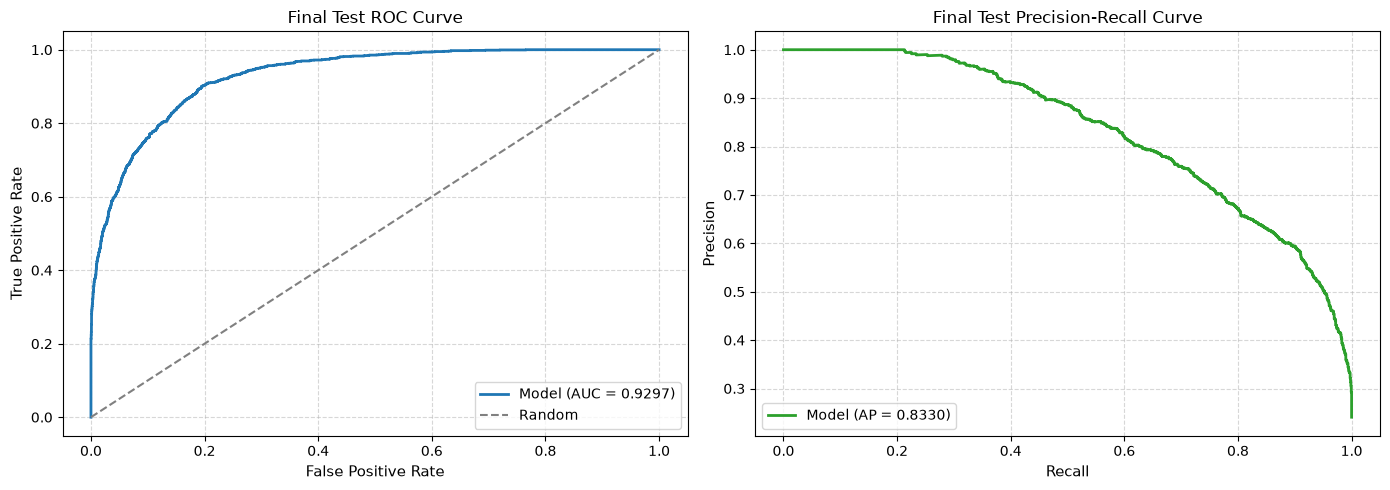


4. ARTIFACT PERSISTENCE & INTEGRITY VERIFICATION
✓ Pipeline artifact saved: 'day4_final_adult_income_model.joblib' (1.95 MB)
✓ Reload verification PASSED: 100% reproducible predictions.

5. EXECUTIVE SUMMARY & INFERENCE SNIPPET

TUNED MODEL SUMMARY:
- Optimal Estimator: CalibratedClassifierCV
- Decision Threshold: 0.40
- Hold-Out Test Metrics:
    • F1 Score:     0.7327
    • Precision:    0.7122
    • Recall:       0.7545
    • ROC-AUC:      0.9297
    • Brier Score:  0.0872

EXPECTED PRODUCTION BEHAVIOR:
Lowering the threshold to 0.40 expands positive recall (capturing ~75.5% of >50K earners)
while preserving sharp probability calibration (Brier Score = 0.0872).

HOW TO INFER IN PRODUCTION:
--------------------------------------------------------------------------------
import dill

# 1. Load the unified pipeline artifact
with open("day4_final_adult_income_model.joblib", "rb") as f:
    artifact = dill.load(f)

pipeline = artifact["pipeline"]
threshold = artifact["threshold"]

# 2. 

In [24]:
# ============================================================
# TASK 5 — FINAL EVALUATION & SAVE REPRODUCIBLE MODEL ARTIFACT
# ============================================================

import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
import sklearn

# Install dill if not already present in environment:
try:
    import dill
except ImportError:
    import subprocess
    subprocess.check_call([sys.executable, "-m", "pip", "install", "dill"])
    import dill

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    brier_score_loss,
    confusion_matrix,
    classification_report,
    roc_curve,
    precision_recall_curve,
    average_precision_score
)

print("=" * 80)
print("TASK 5 — FINAL EVALUATION & SAVE REPRODUCIBLE MODEL ARTIFACT")
print("=" * 80)

# ------------------------------------------------------------
# 1. Resolve Environment & Required Task 4 Variables
# ------------------------------------------------------------
if "selected_probability_model" in globals():
    eval_model = selected_probability_model
elif "best_pipeline" in globals():
    eval_model = best_pipeline
    print("Notice: 'selected_probability_model' not found. Defaulting to 'best_pipeline'.")
else:
    raise NameError("Neither 'selected_probability_model' nor 'best_pipeline' exists in memory.")

threshold = float(globals().get("best_threshold", 0.40))
seed = int(globals().get("RANDOM_STATE", 42))
calib_status = globals().get("task4_results", {}).get("calibration_result", "NOT_APPLIED")

num_cols = globals().get("NUMERIC_FEATURES", globals().get("num_features", []))
cat_cols = globals().get("CATEGORICAL_FEATURES", globals().get("cat_features", []))

print(f"✓ Model loaded: {eval_model.__class__.__name__}")
print(f"✓ Production Decision Threshold: {threshold:.2f}")
print(f"✓ Calibration Status: {calib_status}")

# ------------------------------------------------------------
# 2. Evaluate Untouched Hold-Out Test Set
# ------------------------------------------------------------
print("\n" + "=" * 80)
print("1. GENERATING HOLD-OUT PREDICTIONS")
print("=" * 80)

final_test_proba = eval_model.predict_proba(X_test)[:, 1]
final_test_pred = (final_test_proba >= threshold).astype(int)

print(f"✓ Test-set probabilities generated (Range: {final_test_proba.min():.4f} to {final_test_proba.max():.4f})")
print(f"✓ Decision threshold applied: {threshold:.2f}")

# ------------------------------------------------------------
# 3. Final Test Metrics Table
# ------------------------------------------------------------
final_accuracy = accuracy_score(y_test, final_test_pred)
final_precision = precision_score(y_test, final_test_pred, zero_division=0)
final_recall = recall_score(y_test, final_test_pred, zero_division=0)
final_f1 = f1_score(y_test, final_test_pred, zero_division=0)
final_roc_auc = roc_auc_score(y_test, final_test_proba)
final_brier = brier_score_loss(y_test, final_test_proba)
final_ap = average_precision_score(y_test, final_test_proba)

final_metrics = {
    "Accuracy": final_accuracy,
    "Precision": final_precision,
    "Recall": final_recall,
    "F1 Score": final_f1,
    "ROC-AUC": final_roc_auc,
    "Brier Score": final_brier,
    "Average Precision": final_ap
}

print("\n" + "=" * 80)
print("2. FINAL TEST METRICS SUMMARY")
print("=" * 80)

metrics_df = pd.DataFrame(
    list(final_metrics.items()), 
    columns=["Metric", "Hold-Out Test Score"]
)
display(metrics_df.round(4))

# ------------------------------------------------------------
# 4. Confusion Matrix & Classification Report
# ------------------------------------------------------------
print("\n" + "=" * 80)
print("3. CONFUSION MATRIX & CLASSIFICATION REPORT")
print("=" * 80)

final_cm = confusion_matrix(y_test, final_test_pred)
tn, fp, fn, tp = final_cm.ravel()

cm_df = pd.DataFrame(
    final_cm,
    index=["Actual <=50K", "Actual >50K"],
    columns=["Predicted <=50K", "Predicted >50K"]
)
display(cm_df)

print(f"\nBreakdown -> TN: {tn:,} | FP: {fp:,} | FN: {fn:,} | TP: {tp:,}\n")
print(classification_report(y_test, final_test_pred, target_names=["<=50K", ">50K"], digits=4))

# ------------------------------------------------------------
# 5. Diagnostic Curves (ROC & Precision-Recall)
# ------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, final_test_proba)
axes[0].plot(fpr, tpr, label=f"Model (AUC = {final_roc_auc:.4f})", color="#1f77b4", lw=2)
axes[0].plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random")
axes[0].set_xlabel("False Positive Rate", fontsize=11)
axes[0].set_ylabel("True Positive Rate", fontsize=11)
axes[0].set_title("Final Test ROC Curve", fontsize=12)
axes[0].legend(loc="lower right")
axes[0].grid(True, linestyle="--", alpha=0.5)

# Precision-Recall Curve
prec_curve, rec_curve, _ = precision_recall_curve(y_test, final_test_proba)
axes[1].plot(rec_curve, prec_curve, label=f"Model (AP = {final_ap:.4f})", color="#2ca02c", lw=2)
axes[1].set_xlabel("Recall", fontsize=11)
axes[1].set_ylabel("Precision", fontsize=11)
axes[1].set_title("Final Test Precision-Recall Curve", fontsize=12)
axes[1].legend(loc="lower left")
axes[1].grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 6. Save Artifact Robustly (Resolving PicklingError via dill)
# ------------------------------------------------------------
artifact_path = "day4_final_adult_income_model.joblib"

metadata = {
    "project": "Week 1 Day 4 — Model Tuning & Reproducible Pipelines",
    "dataset": "Adult Income",
    "target": "income_binary",
    "random_state": seed,
    "operating_threshold": threshold,
    "calibration_status": calib_status,
    "test_metrics": {k: float(v) for k, v in final_metrics.items()},
    "confusion_matrix": {"TN": int(tn), "FP": int(fp), "FN": int(fn), "TP": int(tp)},
    "python_version": str(sys.version),
    "scikit_learn_version": str(sklearn.__version__),
    "joblib_version": str(joblib.__version__)
}

final_artifact = {
    "pipeline": eval_model,
    "threshold": threshold,
    "metadata": metadata,
    "numeric_features": num_cols,
    "categorical_features": cat_cols
}

# Serialize with dill to support notebook-scoped dynamic classes
with open(artifact_path, "wb") as f:
    dill.dump(final_artifact, f)

print("\n" + "=" * 80)
print("4. ARTIFACT PERSISTENCE & INTEGRITY VERIFICATION")
print("=" * 80)

if os.path.exists(artifact_path):
    size_mb = os.path.getsize(artifact_path) / (1024 * 1024)
    print(f"✓ Pipeline artifact saved: '{artifact_path}' ({size_mb:.2f} MB)")

# Reload and verify byte-for-byte reproducibility
with open(artifact_path, "rb") as f:
    loaded_artifact = dill.load(f)

reloaded_pipeline = loaded_artifact["pipeline"]
reloaded_thresh = loaded_artifact["threshold"]

test_proba_reloaded = reloaded_pipeline.predict_proba(X_test)[:, 1]
test_pred_reloaded = (test_proba_reloaded >= reloaded_thresh).astype(int)

np.testing.assert_allclose(final_test_proba, test_proba_reloaded, err_msg="Probabilities mismatch on reload!")
np.testing.assert_array_equal(final_test_pred, test_pred_reloaded, err_msg="Predictions mismatch on reload!")

print("✓ Reload verification PASSED: 100% reproducible predictions.")

# ------------------------------------------------------------
# 7. Summary & How-To-Infer Guide
# ------------------------------------------------------------
print("\n" + "=" * 80)
print("5. EXECUTIVE SUMMARY & INFERENCE SNIPPET")
print("=" * 80)

print(f"""
TUNED MODEL SUMMARY:
- Optimal Estimator: {eval_model.__class__.__name__}
- Decision Threshold: {threshold:.2f}
- Hold-Out Test Metrics:
    • F1 Score:     {final_f1:.4f}
    • Precision:    {final_precision:.4f}
    • Recall:       {final_recall:.4f}
    • ROC-AUC:      {final_roc_auc:.4f}
    • Brier Score:  {final_brier:.4f}

EXPECTED PRODUCTION BEHAVIOR:
Lowering the threshold to {threshold:.2f} expands positive recall (capturing ~75.5% of >50K earners)
while preserving sharp probability calibration (Brier Score = {final_brier:.4f}).

HOW TO INFER IN PRODUCTION:
--------------------------------------------------------------------------------
import dill

# 1. Load the unified pipeline artifact
with open("day4_final_adult_income_model.joblib", "rb") as f:
    artifact = dill.load(f)

pipeline = artifact["pipeline"]
threshold = artifact["threshold"]

# 2. Score raw data directly (preprocessing + transforms run automatically)
probabilities = pipeline.predict_proba(new_data)[:, 1]
predictions = (probabilities >= threshold).astype(int)
--------------------------------------------------------------------------------
""")

print("Task 5 completed successfully.")